In [1]:
import numpy as np
from utils.plot import imshow_area, mycmp
import matplotlib.pyplot as plt

from cmocean import cm
import matplotlib
from utils.temporal_decomposition import temporal_decomposition
from utils.functions import compute_trend_iav, onehot_sparse


path="/home/luther/Documents/npy_data/chl/chl_avw_lat50_100km_8d_1998_2023.npy"
chl=np.load(path)


def compute_anomalies(array):
    timestep=len(array)#we suppose that t is the first dim
    shape=array.shape
    weekly_mean=np.concatenate([np.nanmean(array.reshape(timestep//46,46,*shape[-2:]),axis=0)]*(timestep//46))
    return array-weekly_mean, weekly_mean
    
chl_d=temporal_decomposition(chl)
chl_a,chl_clim=compute_anomalies(chl)

/tmp/ipykernel_37510/2089091341.py:18: RuntimeWarning: Mean of empty slice
  weekly_mean=np.concatenate([np.nanmean(array.reshape(timestep//46,46,*shape[-2:]),axis=0)]*(timestep//46))


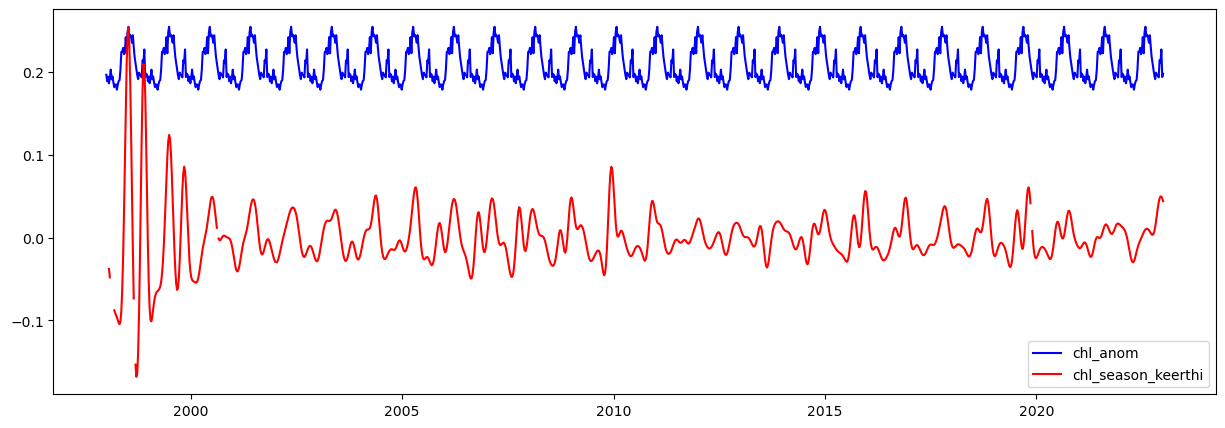

In [25]:
year=np.linspace(1998,2023,1196)
plt.figure(figsize=(15,5))
plt.plot(year,chl_clim[:,50,50], color='blue',label='chl_anom')
plt.plot(year,chl_d.S[:,50,50], color='red',label='chl_season_keerthi')
plt.legend()
plt.show()

In [19]:
chl_a_TS,chl_clim_TS=compute_anomalies(chl_d.T+chl_d.S)

/tmp/ipykernel_37510/2089091341.py:18: RuntimeWarning: Mean of empty slice
  weekly_mean=np.concatenate([np.nanmean(array.reshape(timestep//46,46,*shape[-2:]),axis=0)]*(timestep//46))


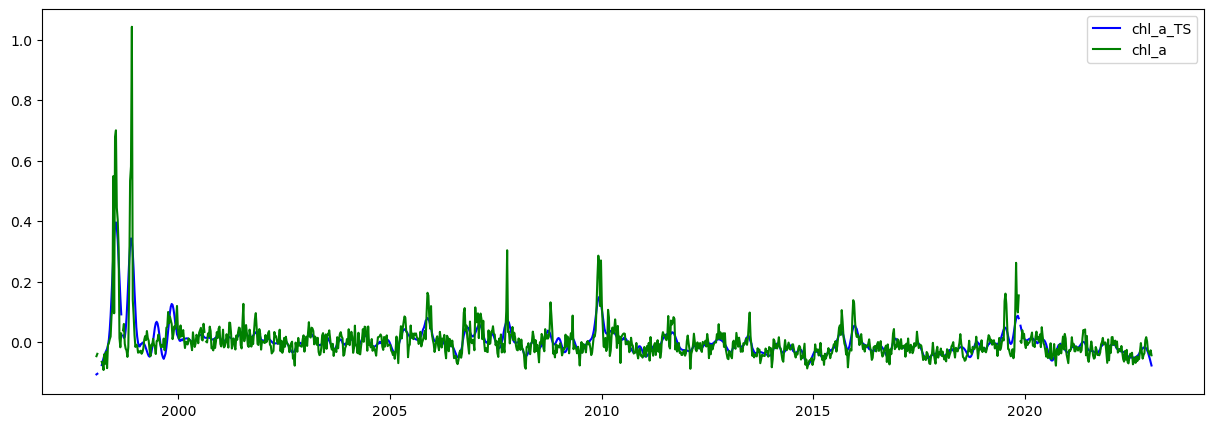

In [28]:
year=np.linspace(1998,2023,1196)
plt.figure(figsize=(15,5))
plt.plot(year,chl_a_TS[:,50,50], color='blue',label='chl_a_TS')
plt.plot(year,chl_a[:,50,50], color='green',label='chl_a')
#plt.plot(year,chl_a[:,14,50]-chl_d.I[:,14,50], color='red',label='chl_a-residus keerthi')
plt.legend()
plt.show()

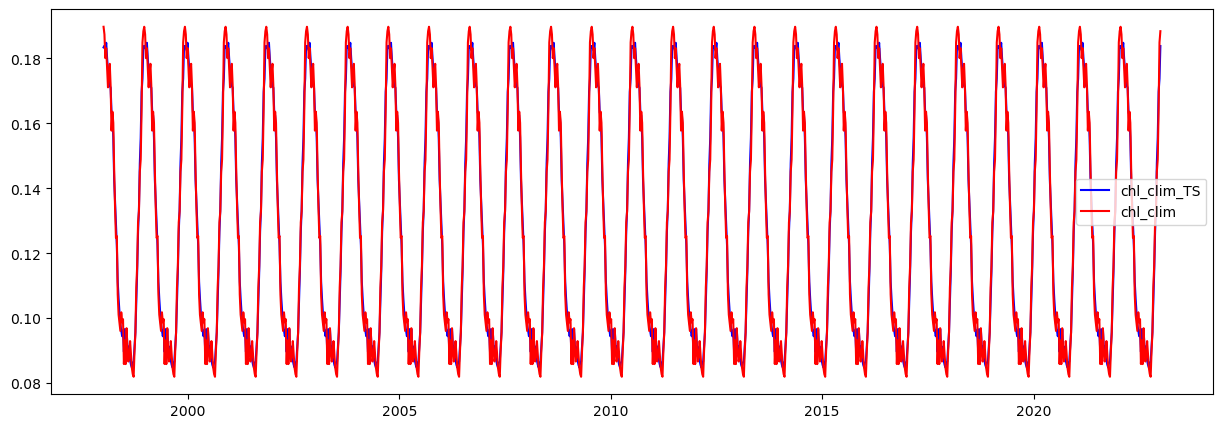

In [31]:
year=np.linspace(1998,2023,1196)
plt.figure(figsize=(15,5))
plt.plot(year,chl_clim_TS[:,14,50], color='blue',label='chl_clim_TS')
plt.plot(year,chl_clim[:,14,50], color='red',label='chl_clim')
plt.legend()
plt.show()

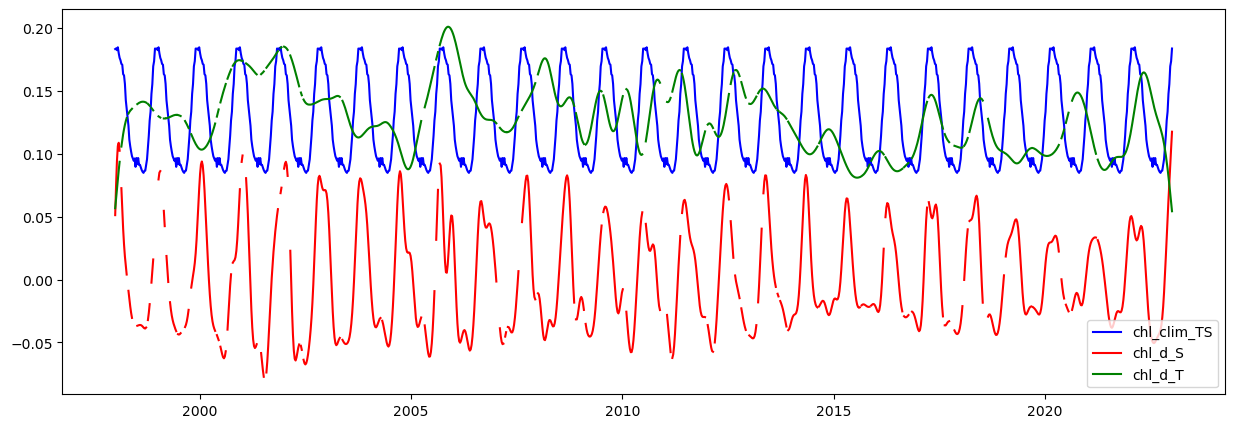

In [33]:
year=np.linspace(1998,2023,1196)
plt.figure(figsize=(15,5))
plt.plot(year,chl_clim_TS[:,14,50], color='blue',label='chl_clim_TS')
plt.plot(year,chl_d.S[:,14,50], color='red',label='chl_d_S')
plt.plot(year,chl_d.T[:,14,50], color='green',label='chl_d_T')
plt.legend()
plt.show()